<a href="https://colab.research.google.com/github/marwa-nassane0052/quantum_ai_experiment/blob/main/Quantumselfattention_ComplexCircuit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

folder_path = '/content/drive/MyDrive/skin_cancer_processed_dataset_data_augmentation'

if os.path.exists(folder_path):
    print(f"Contents of '{folder_path}':")
    for item in os.listdir(folder_path):
        print(item)
else:
    print(f"Folder '{folder_path}' not found. Please check the path and ensure it's in your My Drive.")

Contents of '/content/drive/MyDrive/skin_cancer_processed_dataset_data_augmentation':
y_train.npy
y_test.npy
X_train.npy
X_test.npy


In [3]:
import numpy as np
folder_path = '/content/drive/MyDrive/skin_cancer_processed_dataset_data_augmentation'
X_train = np.load(os.path.join(folder_path, 'X_train.npy'))
y_train = np.load(os.path.join(folder_path, 'y_train.npy'))
X_test = np.load(os.path.join(folder_path, 'X_test.npy'))
y_test = np.load(os.path.join(folder_path, 'y_test.npy'))

In [4]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2200, 3, 128, 128)
y_train shape: (2200,)
X_test shape: (660, 3, 128, 128)
y_test shape: (660,)


**Bulding the hybrid model**

In [5]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 112.0 MB/s eta 0:00:00


In [8]:
import os, time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'PennyLane: {qml.__version__}')
print(f'Device   : {DEVICE}')



CFG = {
    'data_dir'   : '/content/drive/MyDrive/skin_cancer_processed_dataset',
    'epochs'     : 30,
    'batch_size' : 16,   # smaller batch — quantum layer is CPU-bound
    'lr'         : 1e-3,
    # CNN
    'cnn_channels': [32, 64, 256],  # output channels of the 3 conv blocks
    # Self-attention
    'd_model'    : 64,   # attention dimension (projected from CNN features)
    'n_heads'    : 4,    # number of attention heads
    # Quantum
    'n_qubits'   : 4,    # must equal bridge_out_dim
    'q_layers'   : 2,
    # Training
    'patience'   : 8,
    'save'       : 'qsa_hybrid_best.pt',
}
print('Config:', CFG)


folder_path = CFG['data_dir']

X_train = np.load(os.path.join(folder_path, 'X_train.npy'))  # (2200, 3, 128, 128)
y_train = np.load(os.path.join(folder_path, 'y_train.npy'))  # (2200,)
X_test  = np.load(os.path.join(folder_path, 'X_test.npy'))   # ( 660, 3, 128, 128)
y_test  = np.load(os.path.join(folder_path, 'y_test.npy'))   # ( 660,)

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}    y_test  : {y_test.shape}')
n0, n1 = int((y_train==0).sum()), int((y_train==1).sum())
print(f'Balance  →  class 0: {n0} ({n0/len(y_train)*100:.1f}%)  '
      f'class 1: {n1} ({n1/len(y_train)*100:.1f}%)')

# Per-channel z-score normalisation (train statistics applied to both splits)
mean = X_train.mean(axis=(0,2,3), keepdims=True).astype(np.float32)  # (1,3,1,1)
std  = X_train.std (axis=(0,2,3), keepdims=True).astype(np.float32) + 1e-8
X_train = ((X_train - mean) / std).astype(np.float32)
X_test  = ((X_test  - mean) / std).astype(np.float32)
print('Normalised  ✓')

to_t  = lambda a: torch.tensor(a, dtype=torch.float32)
y_tr  = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_te  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(to_t(X_train), y_tr),
                          batch_size=CFG['batch_size'], shuffle=True,  num_workers=2)
test_loader  = DataLoader(TensorDataset(to_t(X_test),  y_te),
                          batch_size=CFG['batch_size'], shuffle=False, num_workers=2)
print('DataLoaders ready  ✓')




# ══════════════════════════════════════════════════════════
# 1. CNN Feature Extractor
# ══════════════════════════════════════════════════════════
# Input  : (N, 3, 128, 128)
# Output : (N, 256, 16, 16)
#
# Spatial trace:
#   128 → Block1+Pool → 64
#    64 → Block2+Pool → 32
#    32 → Block3+Pool → 16

class CNNExtractor(nn.Module):
    def __init__(self, channels=(32, 64, 256)):
        super().__init__()
        c1, c2, c3 = channels
        self.block1 = nn.Sequential(
            nn.Conv2d(  3, c1, 3, padding=1, bias=False),
            nn.BatchNorm2d(c1), nn.GELU(),
            nn.Conv2d( c1, c1, 3, padding=1, bias=False),
            nn.BatchNorm2d(c1), nn.GELU(),
            nn.MaxPool2d(2),                               # 128 → 64
        )
        self.block2 = nn.Sequential(
            nn.Conv2d( c1, c2, 3, padding=1, bias=False),
            nn.BatchNorm2d(c2), nn.GELU(),
            nn.Conv2d( c2, c2, 3, padding=1, bias=False),
            nn.BatchNorm2d(c2), nn.GELU(),
            nn.MaxPool2d(2),                               # 64 → 32
        )
        self.block3 = nn.Sequential(
            nn.Conv2d( c2, c3, 3, padding=1, bias=False),
            nn.BatchNorm2d(c3), nn.GELU(),
            nn.Conv2d( c3, c3, 3, padding=1, bias=False),
            nn.BatchNorm2d(c3), nn.GELU(),
            nn.MaxPool2d(2),                               # 32 → 16
        )

    def forward(self, x):                    # (N, 3, 128, 128)
        x = self.block1(x)                   # (N,  32, 64, 64)
        x = self.block2(x)                   # (N,  64, 32, 32)
        x = self.block3(x)                   # (N, 256, 16, 16)
        return x

print('CNNExtractor defined  ✓')



# ══════════════════════════════════════════════════════════
# 2. Classical Self-Attention  (transformer-style)
# ══════════════════════════════════════════════════════════
# The CNN feature map (N, C, H, W) is treated as a sequence:
#   Each spatial position (h,w) is a token → seq_len = H*W = 256
#   Channel dimension C is the token embedding
#
# Step-by-step:
#   (N, 256, 16, 16)  →  flatten spatial  →  (N, 256, 256)  [seq_len=256, d_in=256]
#   Project to d_model                     →  (N, 256, d_model)
#   Compute Q = X Wq,  K = X Wk,  V = X Wv   each (N, 256, d_model)
#   Att_weights = softmax( Q Kᵀ / √d_head )   (N, heads, 256, 256)
#   V_att = Att_weights · V                    (N, 256, d_model)
#   Output projection + residual + LayerNorm

class ClassicalSelfAttention(nn.Module):
    """
    Multi-head self-attention on spatial feature tokens.
    Input/output shape: (N, seq_len, d_model)
    """
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.scale   = math.sqrt(self.d_head)

        # Q, K, V projection matrices
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)

        # Output projection
        self.Wo      = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(d_model)

    def forward(self, x):
        # x : (N, seq_len, d_model)
        N, L, D = x.shape
        H, Dh   = self.n_heads, self.d_head

        # ── Compute Q, K, V ───────────────────────────────────
        Q = self.Wq(x).view(N, L, H, Dh).transpose(1, 2)  # (N, H, L, Dh)
        K = self.Wk(x).view(N, L, H, Dh).transpose(1, 2)  # (N, H, L, Dh)
        V = self.Wv(x).view(N, L, H, Dh).transpose(1, 2)  # (N, H, L, Dh)

        # ── Scaled dot-product attention ──────────────────────
        # scores : (N, H, L, L)
        scores  = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        weights = F.softmax(scores, dim=-1)               # (N, H, L, L)
        weights = self.dropout(weights)

        # ── Weighted sum of values  →  V_att ─────────────────
        V_att = torch.matmul(weights, V)                  # (N, H, L, Dh)
        V_att = V_att.transpose(1, 2).contiguous()        # (N, L, H, Dh)
        V_att = V_att.view(N, L, D)                       # (N, L, d_model)

        # ── Output projection + residual + LayerNorm ─────────
        out = self.norm(x + self.dropout(self.Wo(V_att))) # (N, L, d_model)
        return out

print('ClassicalSelfAttention defined  ✓')


# ══════════════════════════════════════════════════════════
# 3. Quantum VQC Layer
# ══════════════════════════════════════════════════════════
# Input  : (N, n_qubits)  — Tanh-bounded bridge output
# Encoding: AngleEmbedding (RY gates)
#   Each feature xi is encoded as RY(π * xi) on qubit i
#   Since xi ∈ [-1,1], the rotation angle ∈ [-π, π]
# Ansatz : StronglyEntanglingLayers (parameterised rotations + CNOT entanglement)
# Output : (N, n_qubits) Pauli-Z expectation values ∈ [-1, 1]

dev = qml.device('default.qubit', wires=CFG['n_qubits'])

@qml.qnode(dev, interface='torch', diff_method='backprop')
def vqc_circuit(inputs, weights):
    """
    inputs  : 1-D tensor (n_qubits,)          — ONE sample from the bridge
    weights : tensor (n_layers, n_qubits, 3)   — trainable variational params

    Circuit
    ───────
    AngleEmbedding  :  RY(π * xi) on qubit i   encodes V_att features
    StronglyEntanglingLayers  :  Rot(α,β,γ) + CNOT ring   variational transform
    Measure ⟨Zi⟩ on all qubits                  →  (n_qubits,) output
    """
    # Encode: V_att features → qubit rotation angles
    qml.AngleEmbedding(inputs * math.pi, wires=range(CFG['n_qubits']), rotation='Y')

    # Variational transform
    qml.StronglyEntanglingLayers(weights, wires=range(CFG['n_qubits']))

    # Measure all qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(CFG['n_qubits'])]


class QuantumVQCLayer(nn.Module):
    """
    Wraps vqc_circuit as an nn.Module.
    - Registers variational weights as nn.Parameter
    - Processes each sample individually (avoids TorchLayer batch errors)
    - Returns (N, n_qubits) tensor of expectation values
    """
    def __init__(self, n_qubits: int, n_layers: int):
        super().__init__()
        self.n_qubits = n_qubits
        self.weights  = nn.Parameter(
            torch.randn(n_layers, n_qubits, 3) * 0.1
        )

    def forward(self, x):
        # x : (N, n_qubits)
        out = torch.stack([
            torch.stack(vqc_circuit(x[i], self.weights))  # (n_qubits,)
            for i in range(x.shape[0])
        ]).to(torch.float32)                                # (N, n_qubits)
        return out


print('QuantumVQCLayer defined  ✓')



# ══════════════════════════════════════════════════════════
# 4. Full Hybrid Model
# ══════════════════════════════════════════════════════════

class QuantumSelfAttentionHybrid(nn.Module):
    """
    Full pipeline:

    (N,3,128,128)
      ──CNN──►  (N, 256, 16, 16)
      ──reshape──►  (N, 256, 256)   [256 spatial tokens, 256-dim embedding]
      ──proj──►  (N, 256, d_model)  [linear projection to attention dim]
      ──SelfAttn──►  (N, 256, d_model)   V_att  (attended feature tokens)
      ──mean pool──►  (N, d_model)   [aggregate over sequence]
      ──bridge FC──►  (N, n_qubits)  [project down + Tanh → [-1,1]]
      ──VQC──►  (N, n_qubits)        [quantum transformation]
      ──classifier──►  (N, 1)        [final FC + Sigmoid]
    """
    def __init__(self, cfg):
        super().__init__()
        cnn_out_ch = cfg['cnn_channels'][-1]   # 256
        d_model    = cfg['d_model']             # 64
        n_qubits   = cfg['n_qubits']            # 4

        # ── 1. CNN ──────────────────────────────────────────
        self.cnn = CNNExtractor(cfg['cnn_channels'])
        # After CNN: (N, 256, 16, 16)
        # Spatial positions: 16*16 = 256 tokens
        # Each token has 256-dim embedding (channels)

        # ── 2. Token projection: channels → d_model ─────────
        self.token_proj = nn.Linear(cnn_out_ch, d_model)

        # ── 3. Classical Self-Attention ──────────────────────
        self.attention = ClassicalSelfAttention(
            d_model  = d_model,
            n_heads  = cfg['n_heads'],
            dropout  = 0.1,
        )

        # ── 4. Bridge: V_att  →  quantum-ready vector ────────
        # Mean-pool over seq_len then project to n_qubits
        self.bridge = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_qubits),
            nn.Tanh(),             # ∈ [-1,1] — stable for AngleEmbedding
        )

        # 5. Quantum VQC ───────────────────────────────────
        self.vqc = QuantumVQCLayer(n_qubits, cfg['q_layers'])

        # ── 6. Classical FC Classifier ───────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # ── 1. CNN feature extraction ──────────────────────
        feat = self.cnn(x)                          # (N, 256, 16, 16)

        # ── 2. Reshape into token sequence ─────────────────
        N, C, H, W = feat.shape
        # Flatten spatial dims: each (h,w) position = one token
        tokens = feat.view(N, C, H*W)               # (N, 256, 256)
        tokens = tokens.permute(0, 2, 1)            # (N, 256, 256) → (N, seq_len, C)

        # ── 3. Project tokens to d_model ───────────────────
        tokens = self.token_proj(tokens)             # (N, 256, d_model)

        # ── 4. Classical Self-Attention → V_att ────────────
        v_att = self.attention(tokens)               # (N, 256, d_model)

        # ── 5. Aggregate: mean-pool over sequence ──────────
        pooled = v_att.mean(dim=1)                   # (N, d_model)

        # ── 6. Bridge to quantum ────────────────────────────
        q_in = self.bridge(pooled)                   # (N, n_qubits) ∈ [-1,1]

        # ── 7. Quantum VQC transformation ──────────────────
        q_out = self.vqc(q_in)                       # (N, n_qubits) ∈ [-1,1]

        # ── 8. Classical FC classifier ──────────────────────
        return self.classifier(q_out)                # (N, 1)


# ── Instantiate & parameter summary ──────────────────────────
model = QuantumSelfAttentionHybrid(CFG).to(DEVICE)

cnn_p  = sum(p.numel() for p in model.cnn.parameters())
proj_p = sum(p.numel() for p in model.token_proj.parameters())
att_p  = sum(p.numel() for p in model.attention.parameters())
bri_p  = sum(p.numel() for p in model.bridge.parameters())
vqc_p  = sum(p.numel() for p in model.vqc.parameters())
cls_p  = sum(p.numel() for p in model.classifier.parameters())
total  = cnn_p + proj_p + att_p + bri_p + vqc_p + cls_p

print(f'CNN Extractor      : {cnn_p:>9,}  params')
print(f'Token Projection   : {proj_p:>9,}  params')
print(f'Self-Attention     : {att_p:>9,}  params  (Wq,Wk,Wv,Wo + LN)')
print(f'Bridge (V_att→VQC) : {bri_p:>9,}  params')
print(f'Quantum VQC        : {vqc_p:>9,}  params  '
      f'(layers={CFG['q_layers']} × qubits={CFG['n_qubits']} × 3 angles)')
print(f'FC Classifier      : {cls_p:>9,}  params')
print(f'{"─"*45}')
print(f'Total              : {total:>9,}  params')



def run_epoch(model, loader, criterion, optimizer, train: bool):
    model.train(train)
    total_loss = correct = total = 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        with torch.set_grad_enabled(train):
            out  = model(X_b)
            loss = criterion(out, y_b)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * X_b.size(0)
        correct    += ((out >= 0.5).float() == y_b).sum().item()
        total      += X_b.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    probs_all, preds_all, labels_all = [], [], []
    for X_b, y_b in loader:
        p = model(X_b.to(DEVICE)).cpu().numpy().flatten()
        probs_all.extend(p)
        preds_all.extend((p >= 0.5).astype(int))
        labels_all.extend(y_b.numpy().flatten().astype(int))
    print('\n── Classification Report ──────────────────────────────')
    print(classification_report(labels_all, preds_all,
                                target_names=['Class 0', 'Class 1']))
    cm = confusion_matrix(labels_all, preds_all)
    print('── Confusion Matrix ───────────────────────────────────')
    print(f'             Predicted 0   Predicted 1')
    print(f'  Actual 0 :   TN={cm[0,0]:4d}       FP={cm[0,1]:4d}')
    print(f'  Actual 1 :   FN={cm[1,0]:4d}       TP={cm[1,1]:4d}')
    try:
        print(f'\n  ROC-AUC : {roc_auc_score(labels_all, probs_all):.4f}')
    except Exception:
        pass

print('Helpers defined  ✓')


criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4)

best_val_acc   = 0.0
patience_count = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f'{"Ep":>4}  {"Tr-Loss":>8}  {"Tr-Acc":>7}  {"Va-Loss":>8}  {"Va-Acc":>7}  {"LR":>9}  {"sec":>6}')
print('─' * 65)

for epoch in range(1, CFG['epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    va_loss, va_acc = run_epoch(model, test_loader,  criterion, optimizer, train=False)
    scheduler.step(va_acc)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    lr_now = optimizer.param_groups[0]['lr']
    flag   = '  ◀ best' if va_acc > best_val_acc else ''
    print(f'{epoch:>4}  {tr_loss:>8.4f}  {tr_acc*100:>6.2f}%  '
          f'{va_loss:>8.4f}  {va_acc*100:>6.2f}%  {lr_now:>9.2e}  {elapsed:>5.1f}s{flag}')

    if va_acc > best_val_acc:
        best_val_acc   = va_acc
        patience_count = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_acc': va_acc, 'history': history}, CFG['save'])
    else:
        patience_count += 1
        if patience_count >= CFG['patience']:
            print(f'\n  Early stopping at epoch {epoch}')
            break

print(f'\nBest validation accuracy : {best_val_acc*100:.2f}%')

PyTorch  : 2.10.0+cpu
PennyLane: 0.44.1
Device   : cpu
Config: {'data_dir': '/content/drive/MyDrive/skin_cancer_processed_dataset', 'epochs': 30, 'batch_size': 16, 'lr': 0.001, 'cnn_channels': [32, 64, 256], 'd_model': 64, 'n_heads': 4, 'n_qubits': 4, 'q_layers': 2, 'patience': 8, 'save': 'qsa_hybrid_best.pt'}
X_train : (2200, 3, 32, 32)   y_train : (2200,)
X_test  : (660, 3, 32, 32)    y_test  : (660,)
Balance  →  class 0: 1100 (50.0%)  class 1: 1100 (50.0%)
Normalised  ✓
DataLoaders ready  ✓
CNNExtractor defined  ✓
ClassicalSelfAttention defined  ✓
QuantumVQCLayer defined  ✓
CNN Extractor      :   804,064  params
Token Projection   :    16,448  params
Self-Attention     :    16,512  params  (Wq,Wk,Wv,Wo + LN)
Bridge (V_att→VQC) :     2,212  params
Quantum VQC        :        24  params  (layers=2 × qubits=4 × 3 angles)
FC Classifier      :        97  params
─────────────────────────────────────────────
Total              :   839,357  params
Helpers defined  ✓
  Ep   Tr-Loss   Tr-Acc 

In [9]:
ckpt = torch.load(CFG['save'], map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Best checkpoint — epoch {ckpt['epoch']}  (val_acc={ckpt['val_acc']*100:.2f}%)")
evaluate(model, test_loader)

Best checkpoint — epoch 6  (val_acc=80.45%)

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

     Class 0       0.93      0.69      0.79       360
     Class 1       0.72      0.94      0.81       300

    accuracy                           0.80       660
   macro avg       0.82      0.82      0.80       660
weighted avg       0.83      0.80      0.80       660

── Confusion Matrix ───────────────────────────────────
             Predicted 0   Predicted 1
  Actual 0 :   TN= 250       FP= 110
  Actual 1 :   FN=  19       TP= 281

  ROC-AUC : 0.8768


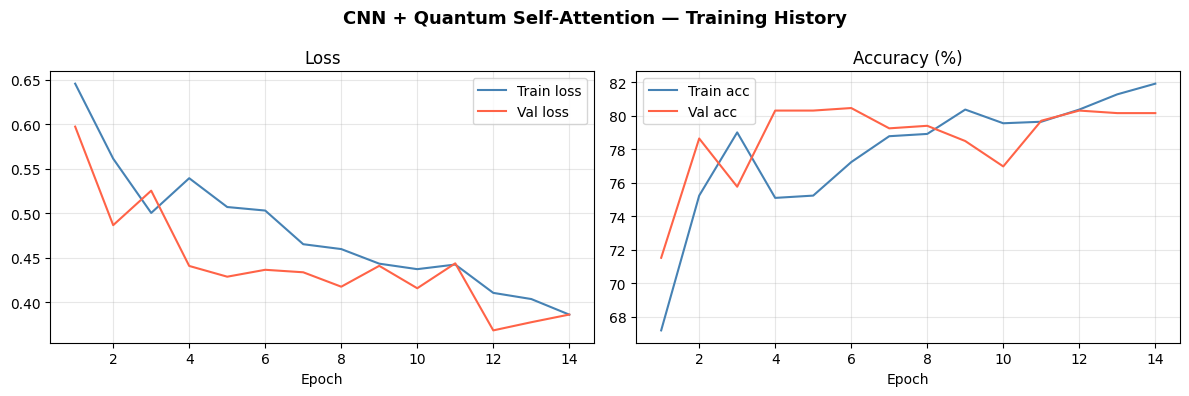

In [10]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_ran, history['train_loss'], label='Train loss', color='steelblue')
ax1.plot(epochs_ran, history['val_loss'],   label='Val loss',   color='tomato')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, [a*100 for a in history['train_acc']], label='Train acc', color='steelblue')
ax2.plot(epochs_ran, [a*100 for a in history['val_acc']],   label='Val acc',   color='tomato')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CNN + Quantum Self-Attention — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()